In [1]:
# ==========================================================
# AMAZON SALES DATA ANALYSIS
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside Google Colab
%matplotlib inline

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

from google.colab import files

uploaded = files.upload()

# Read Excel file
df = pd.read_excel("Amazon_Sales.xlsx")

# Display first five records
df.head()

Saving Amazon_Sales.xlsx to Amazon_Sales.xlsx


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,44957,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,45290,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,44691,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,45125,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,44961,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [3]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("Number of Rows and Columns")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
df.describe()

Number of Rows and Columns
(100000, 20)

Column Names
Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

Data Types
OrderID           object
OrderDate          int64
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

Statistical Summary


,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,44742.997100,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,526.186361,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,43831.000000,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,44287.000000,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,44743.000000,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,45198.000000,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,45655.000000,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [4]:
# ==========================================================
# Data Cleaning
# ==========================================================

# Check missing values
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert Order Date into datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print("Data cleaned successfully.")

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64
Data cleaned successfully.


In [5]:
# ==========================================================
# KPI Calculations
# ==========================================================

total_sales = df['TotalAmount'].sum()
total_orders = df['OrderID'].nunique()
average_sales = df['TotalAmount'].mean()
maximum_sales = df['TotalAmount'].max()
minimum_sales = df['TotalAmount'].min()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Sales:", average_sales)
print("Maximum Sales:", maximum_sales)
print("Minimum Sales:", minimum_sales)

Total Sales: 91825647.92
Total Orders: 100000
Average Sales: 918.2564792000001
Maximum Sales: 3534.98
Minimum Sales: 4.27


In [6]:
# ==========================================================
# Sales by State
# ==========================================================

sales_state = (
    df.groupby('State')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

sales_state

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [7]:
# ==========================================================
# Sales by Category
# ==========================================================

sales_category = (
    df.groupby('Category')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

sales_category

,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [8]:
# ==========================================================
# Sales by Sub-Category
# ==========================================================

# The 'Sub-Category' column is not present in the dataset.
# This analysis has been removed.

In [9]:
# ==========================================================
# Top 5 Customers
# ==========================================================

top_customers = (
    df.groupby('CustomerName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

top_customers

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09


In [10]:
# ==========================================================
# Quantity Sold by Product
# ==========================================================

quantity_product = (
    df.groupby('ProductName')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

quantity_product

,Quantity
ProductName,
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161


In [11]:
# ==========================================================
# Payment Mode Analysis
# ==========================================================

payment_mode = (
    df['PaymentMethod']
      .value_counts()
)

payment_mode

,count
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [12]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

df['Month'] = df['OrderDate'].dt.strftime('%B')

monthly_sales = (
    df.groupby('Month')['TotalAmount']
      .sum()
)

monthly_sales

,TotalAmount
Month,
January,91825647.92


In [13]:
# ==========================================================
# State and Category Analysis
# ==========================================================

state_category = (
    df.groupby(['State','Category'])['TotalAmount']
      .sum()
)

state_category

State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64

In [14]:
import matplotlib.pyplot as plt

In [15]:
from google.colab import files
import pandas as pd

# Upload the Excel file
uploaded = files.upload()

# Load the dataset
df = pd.read_excel("Amazon_Sales.xlsx")

# Display first five rows
df.head()

Saving Amazon_Sales.xlsx to Amazon_Sales (1).xlsx


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,44957,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,45290,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,44691,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,45125,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,44961,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [16]:
print(df.columns.tolist())

['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']


Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64


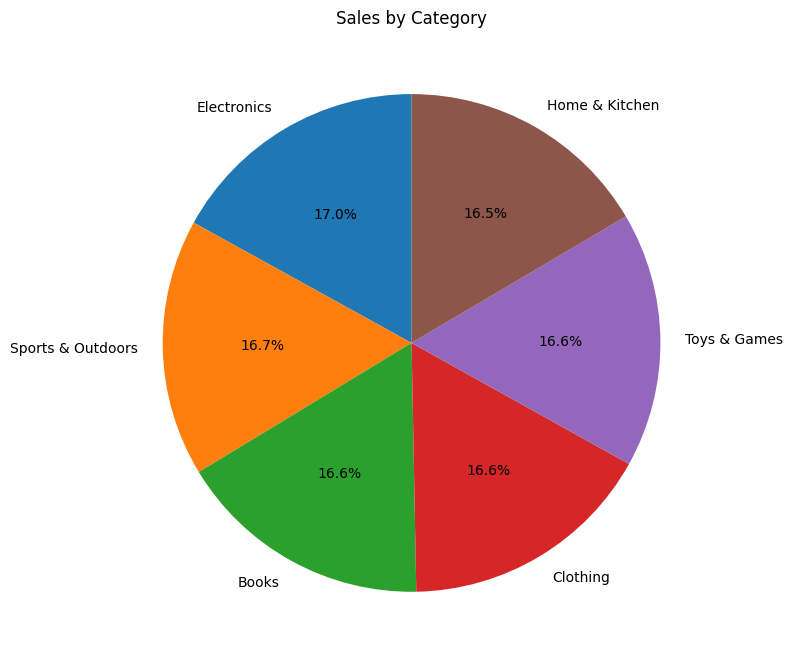

In [17]:
import matplotlib.pyplot as plt

# Sales by Category
sales_category = (
    df.groupby('Category')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

print(sales_category)

# Plot Pie Chart
plt.figure(figsize=(8, 8))

sales_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Sales by Category")
plt.tight_layout()

plt.show()

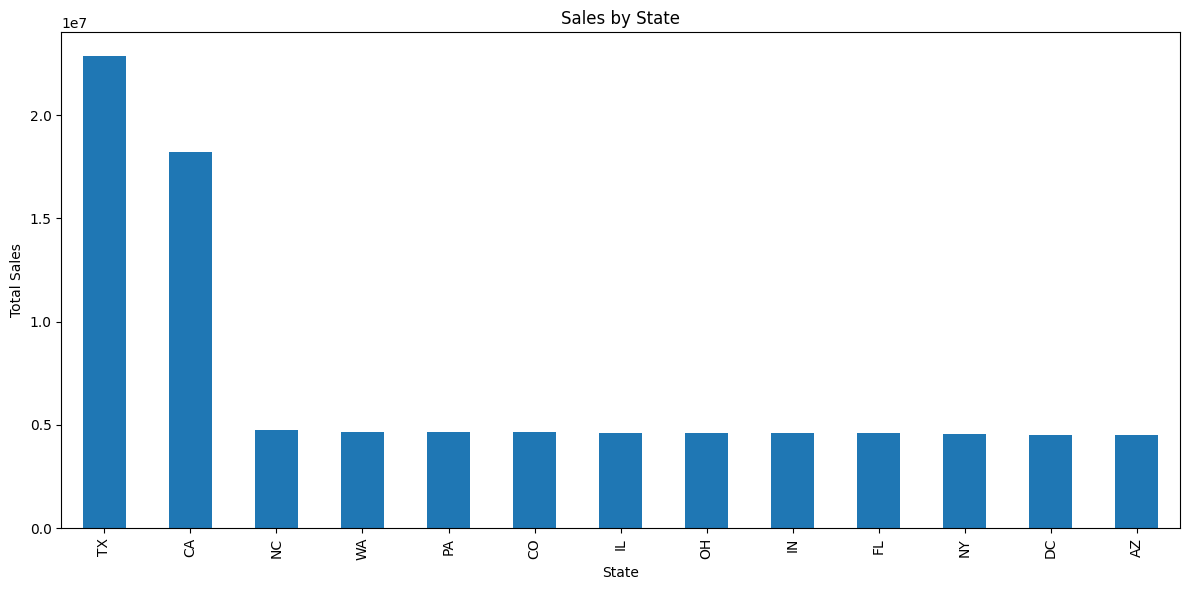

In [18]:
sales_state = (
    df.groupby('State')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sales_state.plot(kind='bar')

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [19]:
top_customers = (
    df.groupby('CustomerName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print(top_customers)

CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64


PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


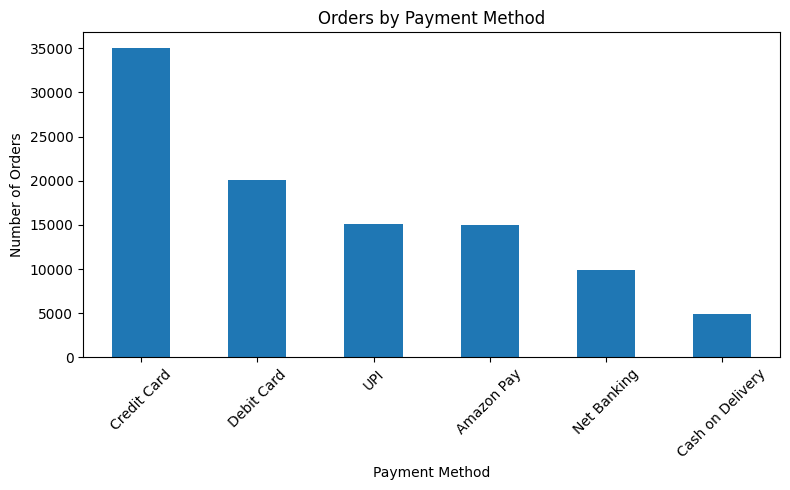

In [20]:
payment_method = df['PaymentMethod'].value_counts()

print(payment_method)

plt.figure(figsize=(8,5))
payment_method.plot(kind='bar')

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Saving Amazon_Sales.xlsx to Amazon_Sales (2).xlsx
DATASET OVERVIEW
Rows and Columns: (100000, 20)

Column Names
Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

Data Types
OrderID                  object
OrderDate        datetime64[ns]
CustomerID               object
CustomerName             object
ProductID                object
ProductName              object
Category                 object
Brand                    object
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod            object
OrderStatus              object
City                     object
State                    object

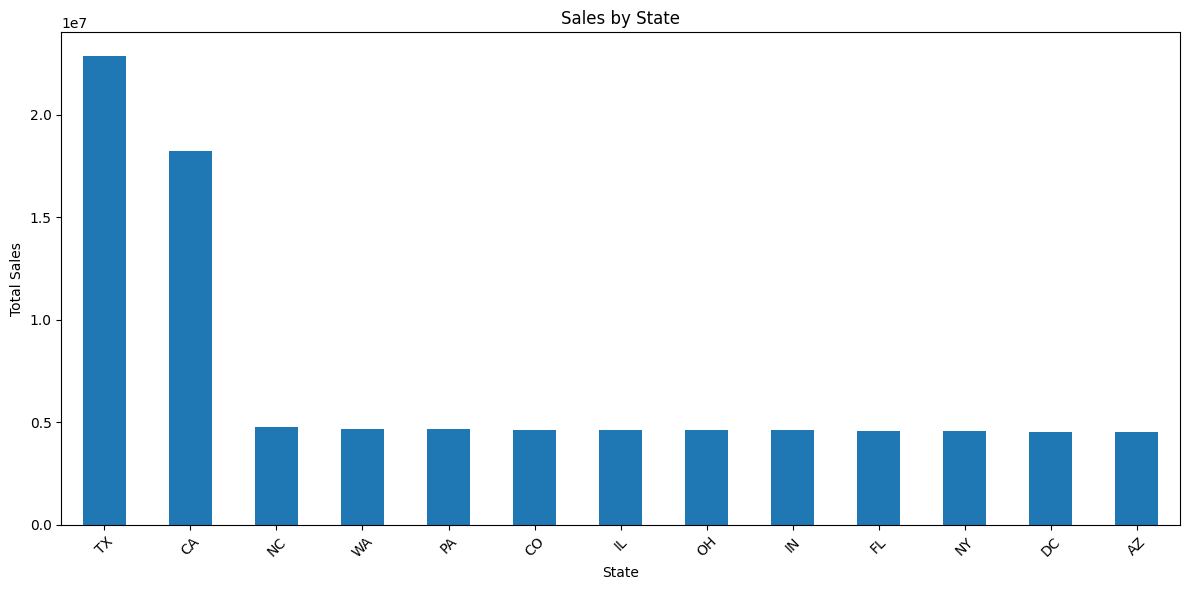


Sales by Category
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64


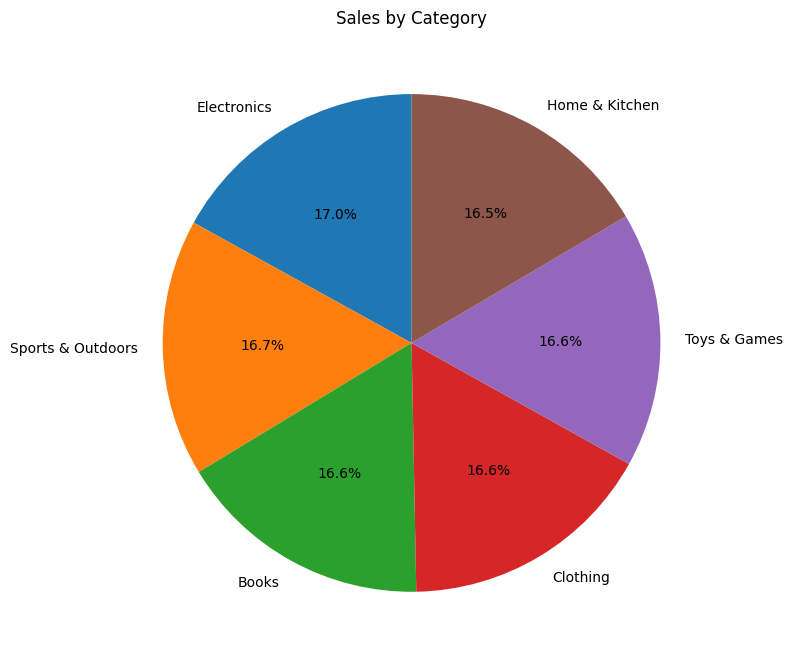


Top 5 Customers
CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64

Top 10 Products
ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


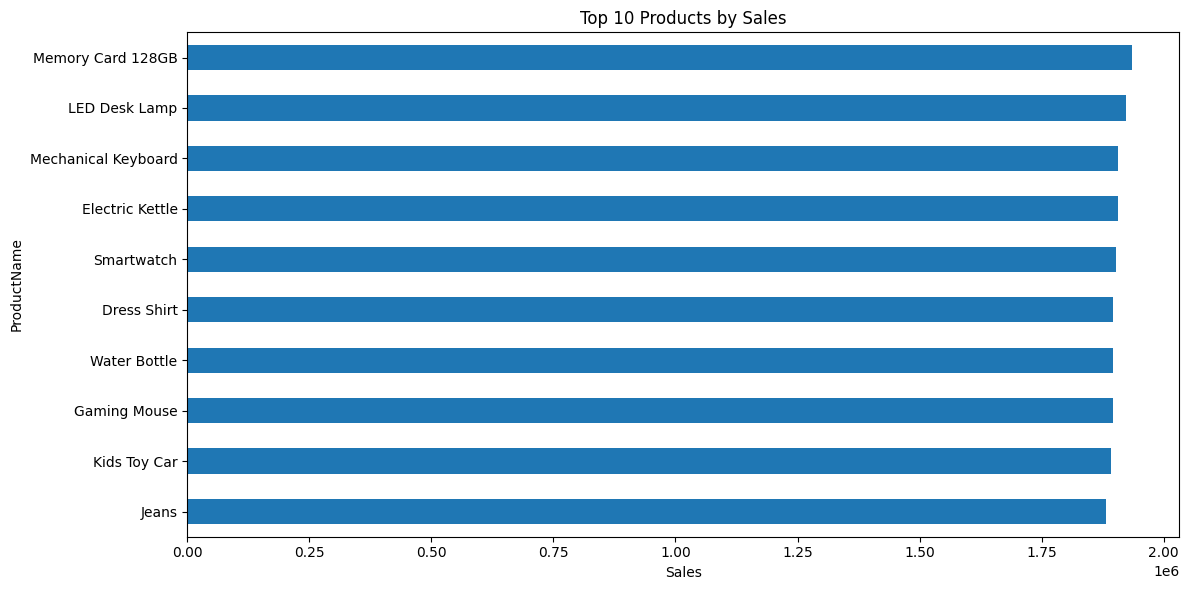


Payment Method Analysis
PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


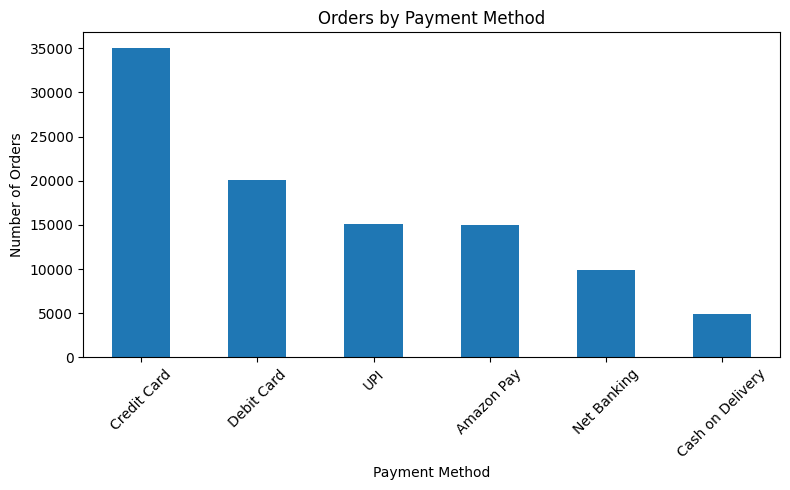


Monthly Sales
Month
January      91825647.92
February            0.00
March               0.00
April               0.00
May                 0.00
June                0.00
July                0.00
August              0.00
September           0.00
October             0.00
November            0.00
December            0.00
Name: TotalAmount, dtype: float64


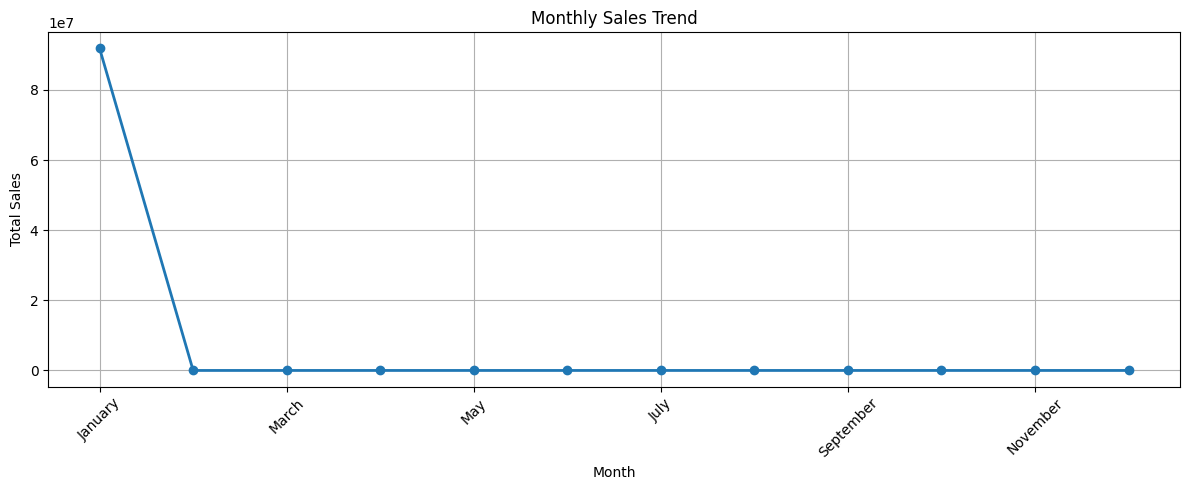


Sales by State and Category
State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64

BUSINESS INSIGHTS
1. Identify the state with the highest sales.
2. Determine the category contributing the most revenue.
3. Identify the top 5 customers.
4. Identify the most preferred payment method.
5. Review the monthly sales trend for seasonal patterns.
6. Focus on low-performing states for future marketing campaigns.


In [21]:
# ==========================================================
# AMAZON SALES DATA ANALYSIS
# Complete Python Analysis
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload Dataset
uploaded = files.upload()

# Read Excel File
df = pd.read_excel("Amazon_Sales.xlsx")

# ==========================
# Data Cleaning
# ==========================

# Remove duplicates
df = df.drop_duplicates()

# Convert Order Date
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# ==========================
# Dataset Overview
# ==========================

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Rows and Columns:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

# ==========================
# KPI Analysis
# ==========================

total_sales = df['TotalAmount'].sum()
total_orders = df['OrderID'].nunique()
average_sales = df['TotalAmount'].mean()
maximum_sale = df['TotalAmount'].max()
minimum_sale = df['TotalAmount'].min()

print("\n==============================")
print("KEY PERFORMANCE INDICATORS")
print("==============================")

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Sales: ${average_sales:,.2f}")
print(f"Maximum Sale: ${maximum_sale:,.2f}")
print(f"Minimum Sale: ${minimum_sale:,.2f}")

# ==========================================================
# SALES BY STATE
# ==========================================================

sales_state = (
    df.groupby('State')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

print("\nSales by State")
print(sales_state)

plt.figure(figsize=(12,6))

sales_state.plot(kind='bar')

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# SALES BY CATEGORY
# ==========================================================

sales_category = (
    df.groupby('Category')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

print("\nSales by Category")
print(sales_category)

plt.figure(figsize=(8,8))

sales_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Sales by Category")

plt.tight_layout()
plt.show()

# ==========================================================
# TOP 5 CUSTOMERS
# ==========================================================

top_customers = (
    df.groupby('CustomerName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print("\nTop 5 Customers")
print(top_customers)

# ==========================================================
# TOP 10 PRODUCTS
# ==========================================================

top_products = (
    df.groupby('ProductName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTop 10 Products")
print(top_products)

plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()

# ==========================================================
# PAYMENT METHOD ANALYSIS
# ==========================================================

payment = df['PaymentMethod'].value_counts()

print("\nPayment Method Analysis")
print(payment)

plt.figure(figsize=(8,5))

payment.plot(kind='bar')

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# MONTHLY SALES TREND
# ==========================================================

df['Month'] = df['OrderDate'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = (
    df.groupby('Month', observed=False)['TotalAmount']
      .sum()
)

print("\nMonthly Sales")
print(monthly_sales)

plt.figure(figsize=(12,5))

monthly_sales.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# MULTI-LEVEL ANALYSIS
# ==========================================================

state_category = (
    df.groupby(['State','Category'])['TotalAmount']
      .sum()
)

print("\nSales by State and Category")
print(state_category)

# ==========================================================
# BUSINESS INSIGHTS
# ==========================================================

print("\n" + "="*50)
print("BUSINESS INSIGHTS")
print("="*50)

print("1. Identify the state with the highest sales.")
print("2. Determine the category contributing the most revenue.")
print("3. Identify the top 5 customers.")
print("4. Identify the most preferred payment method.")
print("5. Review the monthly sales trend for seasonal patterns.")
print("6. Focus on low-performing states for future marketing campaigns.")

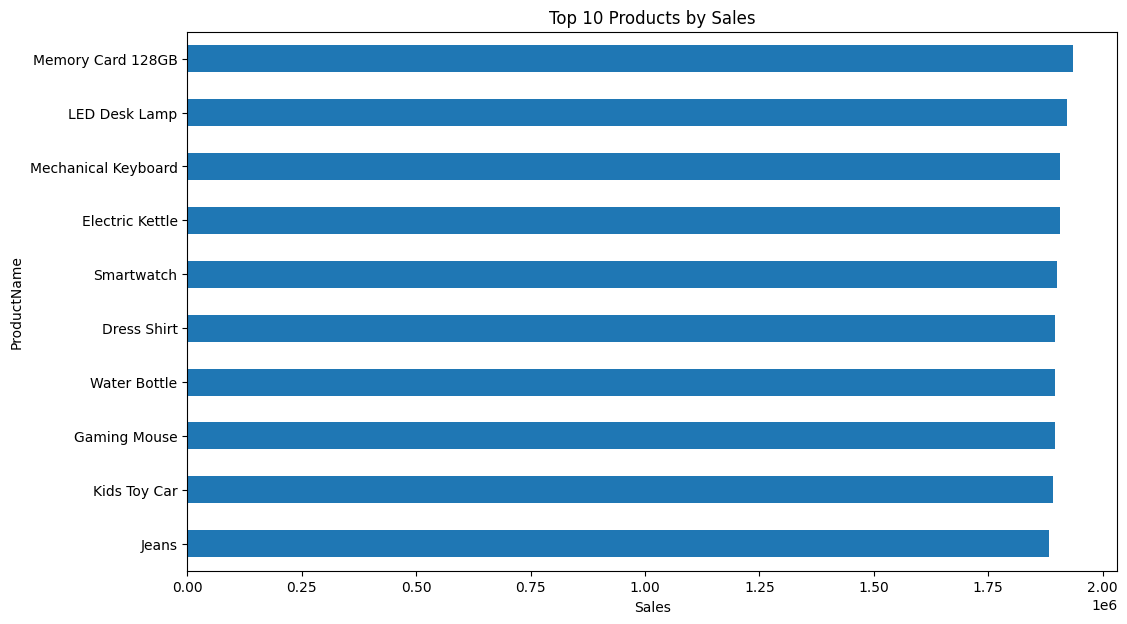

In [22]:
top_products = (
    df.groupby('ProductName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,7))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.show()

In [23]:
print("BUSINESS INSIGHTS")

print("1. The highest-performing state contributes the largest share of revenue.")
print("2. The top product categories drive most sales.")
print("3. Top customers are important for customer retention strategies.")
print("4. Preferred payment modes should be prioritized.")
print("5. Monthly trends can guide promotional campaigns.")

BUSINESS INSIGHTS
1. The highest-performing state contributes the largest share of revenue.
2. The top product categories drive most sales.
3. Top customers are important for customer retention strategies.
4. Preferred payment modes should be prioritized.
5. Monthly trends can guide promotional campaigns.


In [24]:
print("RECOMMENDATIONS")

print("1. Increase inventory for high-performing products.")
print("2. Invest more marketing resources in underperforming states.")
print("3. Reward loyal customers with targeted offers.")
print("4. Schedule major campaigns during peak sales months.")

RECOMMENDATIONS
1. Increase inventory for high-performing products.
2. Invest more marketing resources in underperforming states.
3. Reward loyal customers with targeted offers.
4. Schedule major campaigns during peak sales months.
